In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy import linalg
import networkx as nx # 用于生成复杂的异质拓扑
from scipy.stats import ortho_group
from scipy import stats

In [2]:
class TwoLayerNeuralField:
    def __init__(self, N, constraint_type='conv', kernel_size=5, alpha=0.05, C=100.0):
        self.N = N
        self.alpha = alpha  # Entropy/Anti-collapse
        self.C = C          # Trace constraint
        self.ctype = constraint_type
        
        if constraint_type == 'conv':
            # Learn only a small local kernel
            self.kernel = np.zeros(kernel_size)
            self.kernel[kernel_size//2] = 1.0
        else:
            # Full matrix + Mask
            self.W_full = np.eye(N)
            np.fill_diagonal(self.W_full, np.random.rand(N))
            # self.W_full = np.eye(N) * np.random.uniform(0.1, 1, N)

            dist = np.fromfunction(lambda i, j: np.minimum(np.abs(i-j), N-np.abs(i-j)), (N, N))
            self.mask = (dist <= kernel_size // 2).astype(float)
            
        self.normalize_W()
        W = self.get_W()
        A_init = W @ W.T + np.eye(self.N) * 1e-6
        self.A_init=A_init

    def normalize_W(self):
        """Strictly enforce Tr(WW^T) = C"""
        W = self.get_W()
        current_tr = np.trace(W @ W.T)
        scale = np.sqrt(self.C / current_tr)
        if self.ctype == 'conv':
            self.kernel *= scale
        else:
            self.W_full *= scale

    def get_W(self):
        if self.ctype == 'conv':
            # Build circulant W from kernel
            W = np.zeros((self.N, self.N))
            k_full = np.zeros(self.N)
            ks = len(self.kernel)
            k_full[:ks//2+1] = self.kernel[ks//2:]
            k_full[-ks//2:] = self.kernel[:ks//2+1]
            for i in range(self.N):
                W[i] = np.roll(k_full, i)
            return W
        else:
            return self.W_full * self.mask

    def update_hebbian(self,v, lr):
        W = self.get_W()
        A = W @ W.T + np.eye(self.N) * 1e-6
        A_inv = np.linalg.inv(A)
        
        # # Hebbian Gradient: dL/dW = 2*(M + alpha*A_inv - beta*I)W
        # # beta is the dynamic pressure to maintain Trace
        # beta = np.trace((M + self.alpha * A_inv) @ (W @ W.T)) / self.C
        # grad_W = 2 * (M + self.alpha * A_inv - beta * np.eye(self.N)) @ W
        
        
        v_projected = v.T @ A @ v  # Scalar: v^T (WW^T) v

        beta = (v_projected + self.alpha * self.N) / self.C
        
        # 4. Calculate grad_W
        # (vv^T @ W) is equivalent to v @ (v^T @ W) which is more efficient: O(NK) instead of O(N^2K)
        term_M_W = v.reshape(-1, 1) @ (v.reshape(1, -1) @ W)
        term_Entropy_W = self.alpha * (A_inv @ W)
        term_Trace_W = beta * W
        
        grad_W = 2 * (term_M_W + term_Entropy_W - term_Trace_W)

        
        
        if self.ctype == 'conv':
            # Project back to kernel (average across diagonals)
            dk = np.zeros_like(self.kernel)
            ks = len(self.kernel)
            for i in range(ks):
                offset = i - ks//2
                dk[i] = np.mean(np.diag(grad_W, k=offset) if offset>=0 else np.diag(grad_W, k=self.N+offset))
            self.kernel += lr * dk
        else:
            self.W_full += lr * grad_W * self.mask
            
        self.normalize_W()

In [3]:
def get_gradients(N, mode='local'):
    x = np.linspace(0, 1, N)
    if mode == 'local':
        # 1. Localized: Only neurons near center care about s
        # return np.exp(-(x - 0.5)**2 / (2 * 0.05**2)).reshape(-1, 1)
        return np.sin(x * 0.5) * np.exp(-0.5 * (x / 15.0)**2) # High freq sensitivity
    
    elif mode == 'global_shift':
        # 2. Global: A wave-like gradient across all neurons
        return np.sin(2 * np.pi * x).reshape(-1, 1)
        # return np.exp(-0.5 * (x / 6.0)**2) # Low freq sensitivity
    
    elif mode == 'mean_field':
        # 3. Mean Field: All neurons care equally

        a=np.ones((N, 1))
        # a[:N//2]=-1
        return a#np.random.choice([1, -1], size=N)#np.ones((N, 1))
        # return np.linspace(0.9,1.0,N)

In [4]:
def calculate_xi_field_theory(A, N):
    """
    Corrected Ginzburg-Landau correlation length calculation.
    xi = sqrt(kappa / m^2)
    """
    # 1. Get eigenvalues and eigenvectors
    # We use eigh because A is symmetric
    vals, vecs = np.linalg.eigh(A)
    
    # Sort them just in case (eigh usually returns sorted)
    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:, idx]
    
    # 2. Identify the 'Mass' (Soft Mode eigenvalue)
    # This is the precision gap. If A is singular, m2 -> 0
    m2 = vals[0]
    
    # 4. Compute Correlation Length
    # Use a small epsilon to avoid division by zero at the critical point
    epsilon = 1e-12
    xi = np.sqrt(1 / (m2 + epsilon))
    
    # 5. Finite Size Clipping
    # Physical xi cannot meaningfully exceed the system size N
    return min(xi, N)

In [5]:
def analyze_spectral_criticality(A_matrix, tol=1e-9):
    """
    Quantifies the criticality of a neural system using spectral methods.
    
    Args:
        A_matrix (np.ndarray): The NxN symmetric precision matrix (inverse covariance).
                               Represents the energy landscape curvature.
        tol (float): Threshold to treat eigenvalues as effectively zero.
        
    Returns:
        dict: Dictionary containing:
            - 'spectral_gap': The smallest non-zero eigenvalue (lambda_min).
            - 'correlation_length': Effective spatial range (xi).
            - 'ipr': Inverse Participation Ratio of the softest mode (Y).
            - 'is_critical': Boolean flag if system is near criticality.
    """
    # 1. Eigen-decomposition (using eigh for symmetric/Hermitian matrices)
    # eigenvalues are returned in ascending order
    evals, evecs = linalg.eigh(A_matrix)
    
    # 2. Identify the "Softest Mode" (Mass Term)
    # In a precision matrix, the smallest eigenvalue corresponds to the 
    # flattest direction in the energy landscape (highest variance).
    lambda_min = evals[0]
    
    # Handle numerical instability if lambda_min is practically zero (Goldstone mode)
    if lambda_min < tol:
        xi = np.inf
    else:
        # Formula: xi ~ 1 / sqrt(lambda_min)
        xi = 1.0 / np.sqrt(lambda_min)
        
    # 3. Compute Inverse Participation Ratio (IPR)
    # IPR quantifies the spatial extent of the eigenmode.
    # Y = sum(u_i^4) for normalized u.
    # If Y ~ 1/N -> Delocalized (Critical/Collective state).
    # If Y ~ 1   -> Localized (Single neuron state).
    
    u_soft = evecs[:, 0]  # Eigenvector corresponding to lambda_min
    
    # Ensure normalization (eigh usually returns normalized vectors, but good to be safe)
    u_soft = u_soft / np.linalg.norm(u_soft)
    
    ipr = np.sum(u_soft ** 4)
    
    return {
        "spectral_gap": lambda_min,
        "correlation_length": xi,
        "ipr": ipr,
        "regime": "Delocalized (Critical)" if ipr < (5.0 / len(A_matrix)) else "Localized",
        "soft_mode_vector": u_soft
    }

In [6]:
result_dir='result/'
modes=['local','global_shift','mean_field']
N_arr=np.array([100,200,300,400,500,600])
C = 2e2
# H_weight=1e-3
H_weight = 0
topo='random'

constraint='mask'

现在神经元的个数是： 100
Spectral Gap (Mass^2): 0.0000
Correlation Length:      327.0339
IPR (Localization):      0.0917
Regime:                  Localized
现在神经元的个数是： 200
Spectral Gap (Mass^2): 0.0000
Correlation Length:      881.2989
IPR (Localization):      0.0422
Regime:                  Localized
现在神经元的个数是： 300
Spectral Gap (Mass^2): 0.0000
Correlation Length:      996.4046
IPR (Localization):      0.0276
Regime:                  Localized
现在神经元的个数是： 400
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.4836
IPR (Localization):      0.0208
Regime:                  Localized
现在神经元的个数是： 500
Spectral Gap (Mass^2): 0.0000
Correlation Length:      997.4459
IPR (Localization):      0.0165
Regime:                  Localized
现在神经元的个数是： 600
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.7794
IPR (Localization):      0.0138
Regime:                  Localized


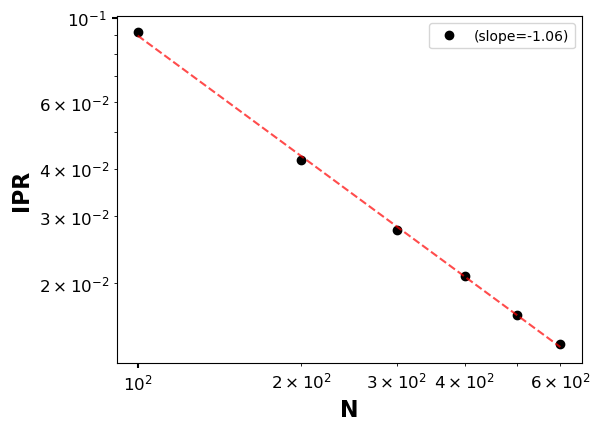

现在神经元的个数是： 100
Spectral Gap (Mass^2): 0.0000
Correlation Length:      893.4408
IPR (Localization):      0.0917
Regime:                  Localized
现在神经元的个数是： 200
Spectral Gap (Mass^2): 0.0000
Correlation Length:      994.4836
IPR (Localization):      0.0431
Regime:                  Localized
现在神经元的个数是： 300
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.9416
IPR (Localization):      0.0282
Regime:                  Localized
现在神经元的个数是： 400
Spectral Gap (Mass^2): 0.0000
Correlation Length:      998.1515
IPR (Localization):      0.0209
Regime:                  Localized
现在神经元的个数是： 500
Spectral Gap (Mass^2): 0.0000
Correlation Length:      993.2234
IPR (Localization):      0.0160
Regime:                  Localized
现在神经元的个数是： 600
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.9712
IPR (Localization):      0.0138
Regime:                  Localized


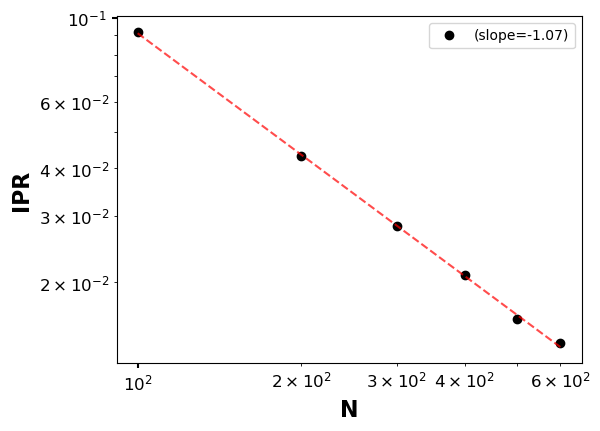

现在神经元的个数是： 100
Spectral Gap (Mass^2): 0.0000
Correlation Length:      207.3975
IPR (Localization):      0.0757
Regime:                  Localized
现在神经元的个数是： 200
Spectral Gap (Mass^2): 0.0000
Correlation Length:      997.2323
IPR (Localization):      0.0431
Regime:                  Localized
现在神经元的个数是： 300
Spectral Gap (Mass^2): 0.0000
Correlation Length:      934.0796
IPR (Localization):      0.0179
Regime:                  Localized
现在神经元的个数是： 400
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.9286
IPR (Localization):      0.0209
Regime:                  Localized
现在神经元的个数是： 500
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.9673
IPR (Localization):      0.0167
Regime:                  Localized
现在神经元的个数是： 600
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.9998
IPR (Localization):      0.0138
Regime:                  Localized


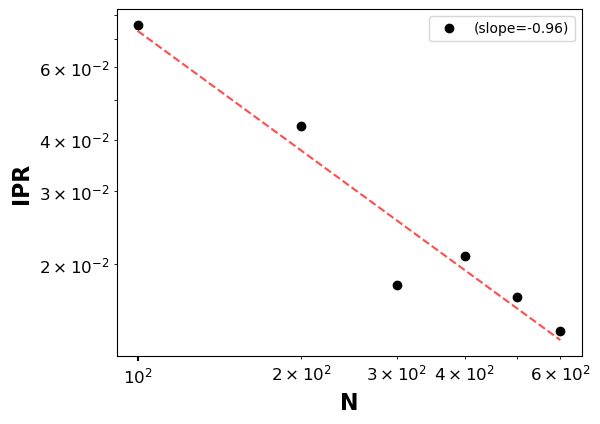

现在神经元的个数是： 100
Spectral Gap (Mass^2): 0.0000
Correlation Length:      534.0506
IPR (Localization):      0.0916
Regime:                  Localized
现在神经元的个数是： 200
Spectral Gap (Mass^2): 0.0000
Correlation Length:      996.5875
IPR (Localization):      0.0431
Regime:                  Localized
现在神经元的个数是： 300
Spectral Gap (Mass^2): 0.0000
Correlation Length:      997.6522
IPR (Localization):      0.0275
Regime:                  Localized
现在神经元的个数是： 400
Spectral Gap (Mass^2): 0.0000
Correlation Length:      993.1615
IPR (Localization):      0.0205
Regime:                  Localized
现在神经元的个数是： 500
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.8104
IPR (Localization):      0.0142
Regime:                  Localized
现在神经元的个数是： 600
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.9995
IPR (Localization):      0.0138
Regime:                  Localized


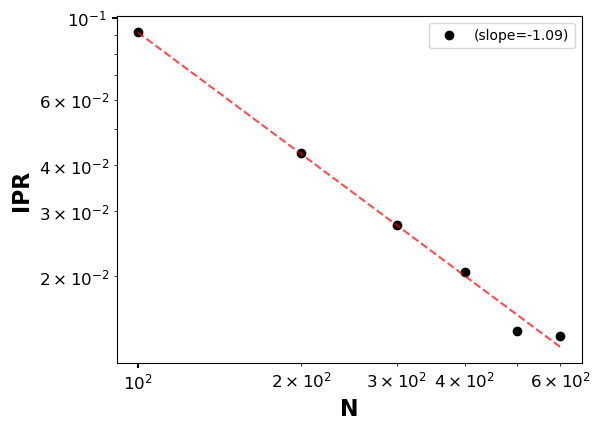

现在神经元的个数是： 100
Spectral Gap (Mass^2): 0.0000
Correlation Length:      260.4922
IPR (Localization):      0.0906
Regime:                  Localized
现在神经元的个数是： 200
Spectral Gap (Mass^2): 0.0000
Correlation Length:      821.7029
IPR (Localization):      0.0427
Regime:                  Localized
现在神经元的个数是： 300
Spectral Gap (Mass^2): 0.0000
Correlation Length:      983.6426
IPR (Localization):      0.0275
Regime:                  Localized
现在神经元的个数是： 400
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.8447
IPR (Localization):      0.0209
Regime:                  Localized
现在神经元的个数是： 500
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.7484
IPR (Localization):      0.0166
Regime:                  Localized
现在神经元的个数是： 600
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.9491
IPR (Localization):      0.0138
Regime:                  Localized


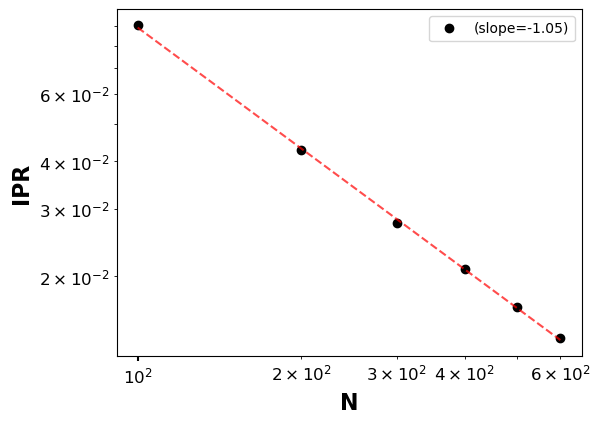

In [7]:
ipr_arrs=[]
for ei in range(5):
    # A_arr=[]
    # W_arr=[]
    # Ai_arr=[]
    # Wi_arr=[]
    ipr_n=[]
    for N in N_arr:
        kernel_s = N//10 # Note:kernel 的大小和fisher information的大小直接相关。好像是一一对应的？ -> # NOTE: Fisher Information 并不是由网络规模决定，而是由局部连接结构决定?
        print("现在神经元的个数是：", N)
        f_prime = get_gradients(N, mode=modes[2])
        model = TwoLayerNeuralField(N, constraint_type=constraint,kernel_size=kernel_s, alpha=H_weight, C=C)
        # h_fisher, h_xi,h_xi_fft= [], [],[]
    
        for _ in range(600):
            W = model.get_W()
            A =  W @ W.T + np.eye(N)*1e-6
            fi=f_prime.T @ A @ f_prime
            # h_fisher.append(fi.item())
            
            # h_xi.append(calculate_xi_field_theory(A, N))
            # # h_xi_fft.append(calculate_xi_fourier_method(A, N))
                    
            model.update_hebbian(f_prime, lr=0.001)

        # print("训练后的A的对角元", np.diag(A))
        # A_arr.append(A)
        # W_arr.append(model.W)
        # Ai_arr.append(model.A_init)
        # Wi_arr.append(model.W_init)
        # np.save(result_dir+'A'+str(N)+'_mat.npy',A)
    
        results = analyze_spectral_criticality(A)
        
        print(f"Spectral Gap (Mass^2): {results['spectral_gap']:.4f}")
        print(f"Correlation Length:      {results['correlation_length']:.4f}")
        print(f"IPR (Localization):      {results['ipr']:.4f}")
        print(f"Regime:                  {results['regime']}")
        ipr_n.append(results['ipr'])
    
    ipr_arr=np.array(ipr_n)
    slope, intercept, r, p, std = linregress(np.log10(N_arr), np.log10(ipr_arr))
    
    
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['xtick.major.width'] = 1.5
    plt.rcParams['ytick.major.width'] = 1.5
    
    fig,ax=plt.subplots(figsize=(6, 4.5))
    ax.loglog(N_arr, ipr_arr, 'o', color='black', label=f'(slope={slope:.2f})')
    ax.loglog(N_arr, 10**intercept * N_arr**slope, '--', alpha=0.7,color='red')
    
    plt.xlabel('N',fontsize=16,fontweight='bold')
    plt.ylabel('IPR',fontsize=16,fontweight='bold')
    
    
    plt.legend()
    # plt.savefig(result_dir+'IPR.png',bbox_inches='tight',dpi=300)
    plt.show()
    # if slope>-1.15 and slope<-0.85:
    #     ipr_arrs.append(ipr_arr)

    ipr_arrs.append(ipr_arr)
    
    # np.save(result_dir+'IPR.npy',ipr_arr)



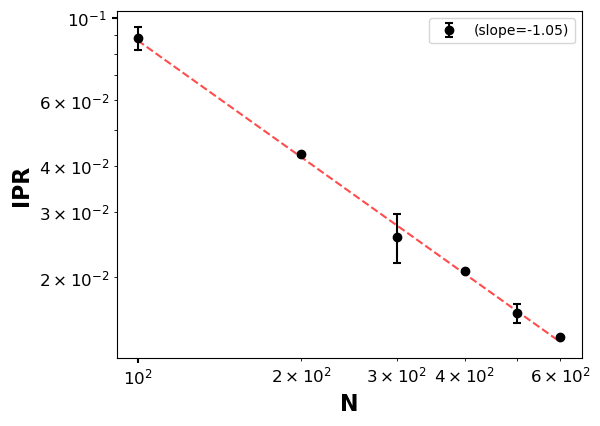

In [8]:
ipr_arrs=np.asarray(ipr_arrs)
slope, intercept, r, p, std = linregress(np.log10(N_arr), np.log10(np.mean(ipr_arrs,axis=0)))

# Calculate mean and std
mean_ipr = np.mean(ipr_arrs, axis=0)
std_ipr = np.std(ipr_arrs, axis=0)

plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

fig,ax=plt.subplots(figsize=(6, 4.5))

lower_err = mean_ipr - (mean_ipr - std_ipr)  # or however you want to define it
upper_err = (mean_ipr + std_ipr) - mean_ipr
ax.errorbar(N_arr, mean_ipr, 
            yerr=[lower_err, upper_err], 
            fmt='o', 
            color='black', 
            capsize=3,
            capthick=1.5,
            elinewidth=1.5,
            label=f'(slope={slope:.2f})')

# Fit line
ax.loglog(N_arr, 10**intercept * N_arr**slope, '--', alpha=0.7, color='red')

plt.xlabel('N', fontsize=16, fontweight='bold')
plt.ylabel('IPR', fontsize=16, fontweight='bold')

plt.legend()
plt.savefig(result_dir+'IPR.png', bbox_inches='tight', dpi=300)
plt.show()

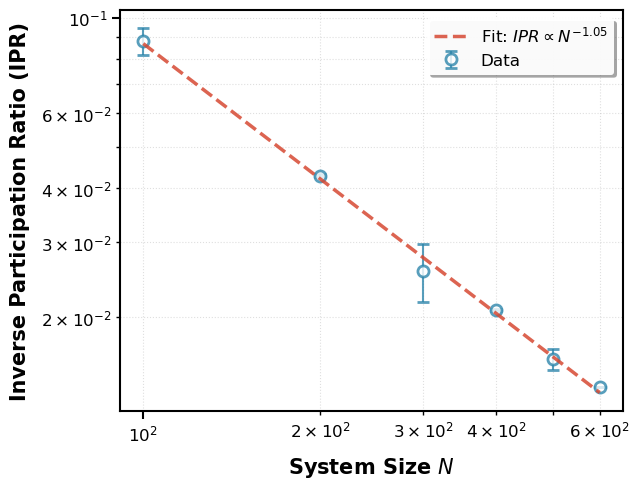

In [9]:
ipr_arrs=np.asarray(ipr_arrs)
slope, intercept, r, p, std = linregress(np.log10(N_arr), np.log10(np.mean(ipr_arrs,axis=0)))

# Calculate mean and std
mean_ipr = np.mean(ipr_arrs, axis=0)
std_ipr = np.std(ipr_arrs, axis=0)
lower_err = mean_ipr - (mean_ipr - std_ipr)  # or however you want to define it
upper_err = (mean_ipr + std_ipr) - mean_ipr

# Set style parameters
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.edgecolor'] = 'none'

fig,ax=plt.subplots(figsize=(6.5, 5))

# Define color palette
colors = {
    'data': '#2E86AB',      # Blue
    'fit': '#D64933',       # Red
    'error': '#2E86AB',     # Same as data
    'fill': '#2E86AB'       # For fill between
}

# Plot with error bars - semi-transparent fill for better visual
ax.errorbar(N_arr, mean_ipr, 
            yerr=[lower_err, upper_err], 
            fmt='o', 
            color=colors['data'],
            markersize=8,
            markerfacecolor='white',
            markeredgewidth=2,
            capsize=4,
            capthick=2,
            elinewidth=1.5,
            ecolor=colors['error'],
            alpha=0.8,
            # label=f'Data (slope={slope:.2f})',
            label='Data',
            zorder=2)

# # Add shaded error region (optional - more visual)
# ax.fill_between(N_arr, 
#                 mean_ipr - std_ipr, 
#                 mean_ipr + std_ipr, 
#                 color=colors['fill'],
#                 alpha=0.15,
#                 zorder=1)

# Fit line with better styling
ax.loglog(N_arr, 10**intercept * N_arr**slope, 
          '--', 
          linewidth=2.5,
          color=colors['fit'],
          alpha=0.85,
          label=f'Fit: $IPR \\propto N^{{{slope:.2f}}}$',
          zorder=3)

# # Add R² value annotation
# r_squared = r**2
# ax.text(0.05, 0.95, 
#         f'$R^2 = {r_squared:.3f}$',
#         transform=ax.transAxes,
#         fontsize=13,
#         fontweight='bold',
#         verticalalignment='center',
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))

# Customize axis labels
plt.xlabel('System Size $N$', fontsize=15, fontweight='bold', labelpad=8)
plt.ylabel('Inverse Participation Ratio (IPR)', fontsize=15, fontweight='bold', labelpad=8)

# Customize legend
legend = plt.legend(frameon=True, 
                   fontsize=12,
                   loc='best', # 这个做hetero的，因为文章主要是写的是hetero的。补充做的homo的放一个mean_field的就行了
                   fancybox=True,
                   shadow=True,
                   framealpha=0.95)
legend.get_frame().set_linewidth(0)

# Add grid for better readability
ax.grid(True, which='both', linestyle=':', alpha=0.4, linewidth=0.8)
ax.set_axisbelow(True)

# Tweak tick parameters
ax.tick_params(axis='both', which='major', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', length=3, width=1)

# Adjust layout
plt.tight_layout()

plt.savefig(result_dir+f'IPR_{modes[1]}.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()